In [278]:
import pandas as pd
import numpy as np

df = pd.read_parquet('turbo_df.parquet')
df.head()

,Link,Classified Date,Band,Model,Year,Ban type,Color,Engine volume,Horsepower,Fuel type,Box,Gear,Is new,Seats count,Owners count,Condition,Supply,Credit,Barter,Price,Currency,Description
0,https://turbo.az/autos/8261904-acura-mdx,29.03.2024,Acura,MDX,2000,Offroader / SUV,Qara,3500,265,Benzin,Avtomat,Tam,No,NaN,NaN,"Vuruğu yoxdur, rənglənməyib",NaN,No,No,12500,AZN,Maşın yaxşı vəziyyətdıdir. Yoxlatdıra bilərsin...
1,https://turbo.az/autos/7960567-aito-m5,31.03.2024,AITO,M5,2023,Offroader / SUV,Ağ,1500,496,Plug-in Hibrid,Avtomat,Tam,Yes,NaN,NaN,"Vuruğu yoxdur, rənglənməyib",Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;...,No,No,52000,USD,NaN
2,https://turbo.az/autos/8344482-alfa-romeo-stelvio,12.04.2024,Alfa Romeo,Stelvio,2022,Offroader / SUV,Qara,2000,280,Benzin,Avtomat,Tam,No,5,1,"Vuruğu yoxdur, rənglənməyib",Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;...,No,Yes,55300,USD,"Resmi servisden alinib,hec bir problemi yoxdu..."
3,https://turbo.az/autos/7758080-alfa-romeo-stelvio,12.04.2024,Alfa Romeo,Stelvio,2017,Offroader / SUV,Yaş Asfalt,2000,280,Benzin,Avtomat,Tam,No,NaN,NaN,"Vuruğu yoxdur, rənglənməyib",Yüngül lehimli disklər;ABS;Yağış sensoru;Mərkə...,No,No,28000,USD,Maşın ölkeye yeni getirilib.Hal hazırda heç bi...
4,https://turbo.az/autos/7450290-alfa-romeo-giulia,11.04.2024,Alfa Romeo,Giulia,2020,Sedan,Boz,2000,200,Benzin,Avtomat,Arxa,No,4,1,"Vuruğu yoxdur, rənglənməyib",Yüngül lehimli disklər;ABS;Mərkəzi qapanma;Par...,No,No,30000,USD,Avtomobilin hec bir problemi yoxdur.


### Inspecting dataset

In [279]:
print(df.shape)
print(df.info())
print(df.describe())

(50833, 22)
<class 'pandas.DataFrame'>
RangeIndex: 50833 entries, 0 to 50832
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Link             50833 non-null  str  
 1   Classified Date  50833 non-null  str  
 2   Band             50833 non-null  str  
 3   Model            50833 non-null  str  
 4   Year             50833 non-null  int64
 5   Ban type         50833 non-null  str  
 6   Color            50833 non-null  str  
 7   Engine volume    50833 non-null  int64
 8   Horsepower       50833 non-null  int64
 9   Fuel type        50833 non-null  str  
 10  Box              50833 non-null  str  
 11  Gear             50833 non-null  str  
 12  Is new           50833 non-null  str  
 13  Seats count      36537 non-null  str  
 14  Owners count     34257 non-null  str  
 15  Condition        50826 non-null  str  
 16  Supply           44781 non-null  str  
 17  Credit           50833 non-null  str  
 18  Barte

In [ ]:
df.drop(df[df["Year"] == 1904].index, inplace=True) # This is the fake sample, needs to drop

### Data Cleaning, Type Conversion, and Missing Value Imputation

In [281]:
df["Seats count"] = pd.to_numeric(
    df["Seats count"].replace("8+", 8),
    errors="coerce"
).astype("Int64")
df["Owners count"] = pd.to_numeric(
    df["Owners count"].replace("4 və daha çox", 4),
    errors="coerce"
).astype("Int64")
df["Seats count"] = df["Seats count"].fillna(df["Seats count"].median()).astype("Int64")
df["Owners count"] = df["Owners count"].fillna(df["Owners count"].median()).astype("Int64")
df["Condition"] = df["Condition"].fillna(df["Condition"].mode()[0])
df["Supply"] = df["Supply"].fillna(df["Supply"].mode()[0])

df.isna().sum()

Link                  0
Classified Date       0
Band                  0
Model                 0
Year                  0
Ban type              0
Color                 0
Engine volume         0
Horsepower            0
Fuel type             0
Box                   0
Gear                  0
Is new                0
Seats count           0
Owners count          0
Condition             0
Supply                0
Credit                0
Barter                0
Price                 0
Currency              0
Description        2402
dtype: int64

### Converting all currency rates to AZN

In [282]:
rates = {"AZN": 1.0, "USD": 1.70, "EUR": 1.95}
df["rate"] = df["Currency"].map(rates) 
df["Price_AZN"] = df["Price"] * df["rate"]

### Dropping unnecessary cols

In [283]:
df = df.drop(columns=['Link', 'Classified Date', 'Description', 'Currency', 'Price', 'rate'])
df = df.drop_duplicates()

### 'Model' feature has almost more than thousand categories, so we decided to keep only top 200 of them

In [ ]:
top_200_models = df["Model"].value_counts().nlargest(200).index

df = df[df["Model"].isin(top_200_models)]

print(df.shape)  # nearly 17% of samples disappeared

(42010, 18)


### One-hot encoding on categorical cols

In [285]:
df = pd.get_dummies(
    df,
    columns=['Model', 'Band', 'Ban type', 'Color', 'Fuel type', 'Box', 'Gear', 'Condition'],
    drop_first=True
)
df.info()


<class 'pandas.DataFrame'>
Index: 42010 entries, 41 to 50813
Columns: 294 entries, Year to Condition_Vuruğu yoxdur, rənglənməyib
dtypes: Int64(2), bool(284), float64(1), int64(3), str(4)
memory usage: 21.1 MB


In [286]:
df['Supply'].value_counts()

Supply
Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;Mərkəzi qapanma;Park radarı;Kondisioner;Oturacaqların isidilməsi;Dəri salon;Ksenon lampalar;Arxa görüntü kamerası;Yan pərdələr;Oturacaqların ventilyasiyası    10216
Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;Mərkəzi qapanma;Park radarı;Kondisioner;Oturacaqların isidilməsi;Dəri salon;Ksenon lampalar;Arxa görüntü kamerası;Oturacaqların ventilyasiyası                  1285
Yüngül lehimli disklər;ABS;Yağış sensoru;Mərkəzi qapanma;Park radarı;Kondisioner;Oturacaqların isidilməsi;Dəri salon;Ksenon lampalar;Arxa görüntü kamerası;Yan pərdələr;Oturacaqların ventilyasiyası          1270
Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;Mərkəzi qapanma;Park radarı;Kondisioner;Oturacaqların isidilməsi;Dəri salon;Ksenon lampalar;Arxa görüntü kamerası                                               1090
Yüngül lehimli disklər;ABS;Lyuk;Yağış sensoru;Mərkəzi qapanma;Park radarı;Kondisioner;Oturacaqların isidilməsi;Dəri salon;Ksenon lampalar;Arxa görünt

### Applying one-hot encoding to 'Supply' feature, by also separating them with ';'

In [287]:
supply_encoded = (
    df['Supply']
    .str.get_dummies(sep=';')
    .add_prefix('Supply_')
)

df = pd.concat(
    [
        df.drop(columns='Supply'),
        supply_encoded
    ],
    axis=1
)
df.shape

(42010, 306)

### Converting dtype of those cols from object to int

In [288]:
str_cols = ['Is new', 'Credit', 'Barter']

df[str_cols] = df[str_cols].replace({
    'Yes': 1,
    'No': 0
}).astype('Int64')
df['Barter'].value_counts()

Barter
0    31628
1    10382
Name: count, dtype: Int64

In [289]:
df.info()

<class 'pandas.DataFrame'>
Index: 42010 entries, 41 to 50813
Columns: 306 entries, Year to Supply_Yüngül lehimli disklər
dtypes: Int64(5), bool(284), float64(1), int64(16)
memory usage: 19.0 MB


### Splitting the dataset

In [290]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

X = df.drop(columns=['Price_AZN'])
y = df['Price_AZN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [291]:
model = RandomForestRegressor(n_estimators=300, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [292]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse)}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2) Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 6208.026716345715
Root Mean Squared Error (RMSE): 6208.026716345715
R-squared (R2) Score: 0.9667


## Comparing train and test results

In [293]:
train_pred = model.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, y_pred))

print(
    "Train RMSE:",
    root_mean_squared_error(y_train, train_pred)
)

print(
    "Test RMSE:",
    root_mean_squared_error(y_test, y_pred)
)

Train R²: 0.9950540735789731
Test R²: 0.9667077280620489
Train RMSE: 2264.6758216484845
Test RMSE: 6208.026716345715


### Feature importance (to see which features affect more to the output)

In [294]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

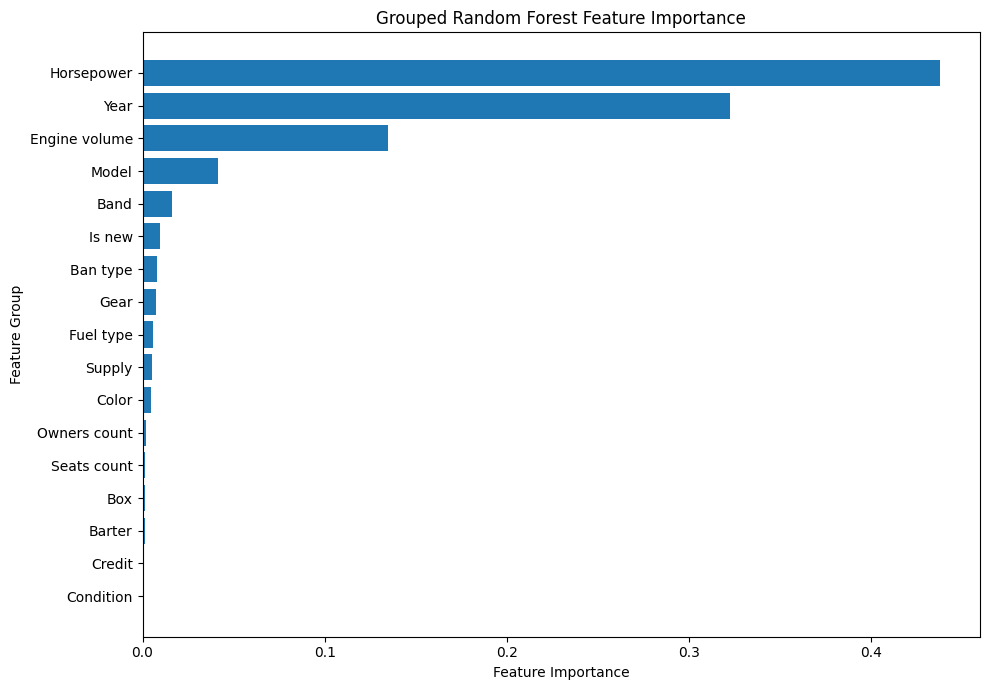

In [295]:
def original_feature_name(col):
    prefixes = [
        "Model_",
        "Band_",
        "Ban type_",
        "Color_",
        "Fuel type_",
        "Box_",
        "Gear_",
        "Condition_",
        "Supply_"
    ]

    for prefix in prefixes:
        if col.startswith(prefix):
            return prefix.rstrip("_")

    return col


importance_df["Feature_Group"] = (
    importance_df["Feature"]
    .apply(original_feature_name)
)

grouped_importance = (
    importance_df
    .groupby("Feature_Group", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

import matplotlib.pyplot as plt

grouped_plot = grouped_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    grouped_plot["Feature_Group"],
    grouped_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature Group")
plt.title("Grouped Random Forest Feature Importance")

plt.tight_layout()
plt.show()